# Math

$$ GELU(x) = xP(X\leq x) = x\phi(x) = x \cdot \frac{1}{2} \Big[1 + erf(x/\sqrt{2}) \Big] $$

$$ GELU_{approximation} = 0.5x(1+\tanh\Big[\sqrt{\frac{2}{\pi}}(x+0.044715x^3)\Big]) $$

$$ ReLU(x) = max(0,x) $$

# Raw Implementation

In [48]:
import numpy as np
from scipy.special import erf
import torch
import torch.nn as nn
import torch.nn.functional as F
import time

import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [49]:
def relu(x):
  y = x * (x>=0)
  return y

def gelu_exact(x):
  y = x / 2 * (1 + erf(x / np.sqrt(2)))
  return y

def gelu_approx(x):
  y = x / 2 * (1 + np.tanh(np.sqrt(2/np.pi) * (x + .044715*x**3)))
  return y

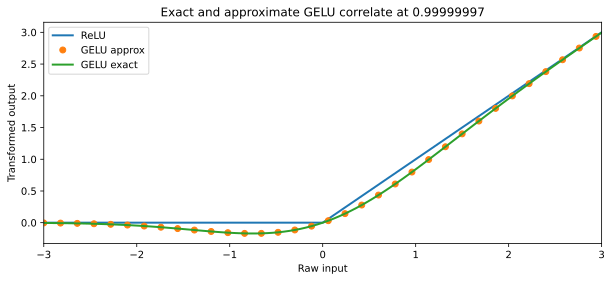

In [50]:
x = np.linspace(-3,3,101)

relu_y  = relu(x)
geluE_y = gelu_exact(x)
geluA_y = gelu_approx(x)

plt.figure(figsize = (10,4))
plt.plot(x, relu_y, linewidth = 2, label = 'ReLU')
plt.plot(x[::3], geluA_y[::3], 'o', linewidth = 2, label = 'GELU approx')
plt.plot(x, geluE_y, linewidth = 2, label = 'GELU exact')

plt.legend()
plt.gca().set(xlabel = 'Raw input', ylabel = 'Transformed output', xlim = x[[0,-1]],
              title = f'Exact and approximate GELU correlate at {np.corrcoef(geluE_y, geluA_y)[0][1]:.8f}')
plt.show()

# Torch Implementation

In [51]:
input = torch.linspace(-3,3,333)
dx    = input[1] - input[0]

# the functions
relu_out = F.relu(input)
gelu_out = F.gelu(input)

# their empirical derivatives
d_relu = torch.diff(relu_out) / dx
d_gelu = torch.diff(gelu_out) / dx

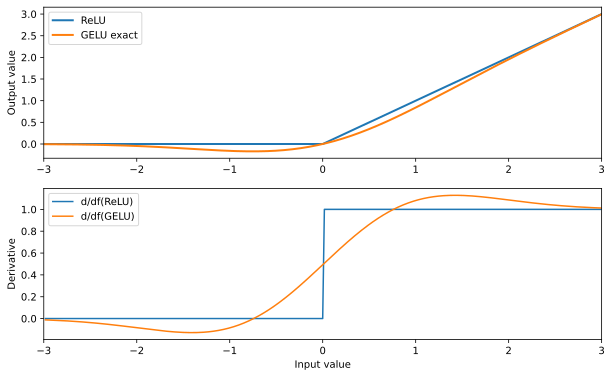

In [52]:
fig, axs = plt.subplots(2,1,figsize = (10,6))

axs[0].plot(input, relu_out, linewidth = 2, label = 'ReLU')
axs[0].plot(input, gelu_out, linewidth = 2, label = 'GELU exact')
axs[0].set_ylabel('Output value')
axs[0].set_xlim([-3,3])
axs[0].legend()

relu_y_diff  = torch.diff(torch.tensor(relu_y))
geluE_y_diff = torch.diff(torch.tensor(geluE_y))

axs[1].plot(input[1:], d_relu, label = 'd/df(ReLU)')
axs[1].plot(input[1:], d_gelu, label = 'd/df(GELU)')
axs[1].set_xlim([-3,3])
axs[1].set_xlabel('Input value')
axs[1].set_ylabel('Derivative')
axs[1].legend()

plt.show()

# ReLU and GELU classes

In [53]:
relu_class = nn.ReLU()
gelu_class = nn.GELU()

relu_out_class = relu_class(input)
gelu_out_class = gelu_class(input)
type(relu_out_class), type(gelu_out_class)

(torch.Tensor, torch.Tensor)

In [54]:
relu_out == relu_out_class

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, Tr

In [55]:
gelu_out == gelu_out_class

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, Tr

# Implementations CPU (Using Numpy functions)

Test on the CPU

In [56]:
num_reps = 10_000
x = np.linspace(-3,3,1001)

print('x device:', x.device, '\n')

print("** --------- CPU / Numpy ------- **")

# relu
start_time = time.time()
for _ in range(num_reps):
  relu(x)
print(f'--- {time.time() - start_time:6.3f} sec. for ReLU')

# exact gelu
start_time = time.time()
for _ in range(num_reps):
  gelu_exact(x)
print(f'--- {time.time() - start_time:6.3f} sec. for exact GELU')

# approximate gelu
start_time = time.time()
for _ in range(num_reps):
  gelu_approx(x)
print(f'--- {time.time() - start_time:6.3f} sec. for approx GELU')

x device: cpu 

** --------- CPU / Numpy ------- **
---  0.018 sec. for ReLU
---  0.107 sec. for exact GELU
---  0.524 sec. for approx GELU


# CPU vs GPU (Using PyTorch functions)

In [57]:
import torch
import torch.nn.functional as F
import time
from scipy.special import erf
import torch
import torch.nn as nn
import numpy as np
import math

In [58]:
def relu(x):
  y = x * (x>=0)
  return y

def gelu_exact(x):
  y = x / 2 * (1 + torch.erf(x / math.sqrt(2)))
  return y

def gelu_approx(x):
  y = x / 2 * (1 + torch.tanh(math.sqrt(2/math.pi) * (x + .044715*x**3)))
  return y

In [64]:
x = torch.randn(1_000_000, device = 'cpu')
num_reps = 100

print('x device:', x.device,'\n')

print("** --------- CPU / PyTorch ------- **")

# relu
start_time = time.time()
for _ in range(num_reps):
  relu(x)
print(f'--- {time.time() - start_time:6.3f} sec. for ReLU')

# exact gelu
start_time = time.time()
for _ in range(num_reps):
  gelu_exact(x)
print(f'--- {time.time() - start_time:6.3f} sec. for exact GELU')

# approximate gelu
start_time = time.time()
for _ in range(num_reps):
  gelu_approx(x)
print(f'--- {time.time() - start_time:6.3f} sec. for approx GELU')

# F.gelu
start_time = time.time()
for _ in range(num_reps):
  F.gelu(x)
print(f'--- {time.time() - start_time:6.3f} sec. for F.gelu')

x device: cpu 

** --------- CPU / PyTorch ------- **
---  0.011 sec. for ReLU
---  0.016 sec. for exact GELU
---  0.027 sec. for approx GELU
---  0.003 sec. for F.gelu


In [67]:
# testing random numbers
x = torch.randn(1_000_000, device = 'cuda')
num_reps = 100

print('x device:', x.device,'\n')

print('** ------- GPU / PyTorch ------- **')

# relu
torch.cuda.synchronize()
start_time = time.time()
for _ in range(num_reps):
  relu(x)
print(f'--- {time.time()-start_time:6.4f} sec. for ReLU')

# exact gelu
torch.cuda.synchronize()
start_time = time.time()
for _ in range(num_reps):
  gelu_exact(x)
print(f'--- {time.time() - start_time:6.4f} sec. for exact GELU')

# approx gelu
torch.cuda.synchronize()
start_time = time.time()
for _ in range(num_reps):
  gelu_approx(x)
print(f'--- {time.time() - start_time:6.4f} sec. for approx GELU')

# F.gelu
torch.cuda.synchronize()
start_time = time.time()
for _ in range(num_reps):
  F.gelu(x)
print(f'--- {time.time() - start_time:6.4f} sec. for F.gelu')


x device: cuda:0 

** ------- GPU / PyTorch ------- **
--- 0.0009 sec. for ReLU
--- 0.0021 sec. for exact GELU
--- 0.0034 sec. for approx GELU
--- 0.0004 sec. for F.gelu


## Visualization

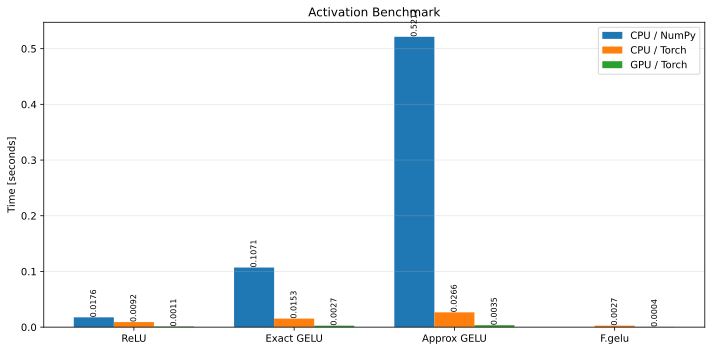

In [71]:
import time
import math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from scipy.special import erf


# ---------- NumPy functions ----------
def relu_np(x):
    return x * (x >= 0)

def gelu_exact_np(x):
    return x / 2 * (1 + erf(x / np.sqrt(2)))

def gelu_approx_np(x):
    return x / 2 * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))


# ---------- Torch functions ----------
def relu_torch(x):
    return x * (x >= 0)

def gelu_exact_torch(x):
    return x / 2 * (1 + torch.erf(x / math.sqrt(2)))

def gelu_approx_torch(x):
    return x / 2 * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * x**3)))


results = {}


# ---------- CPU / NumPy ----------
num_reps = 10_000
x = np.linspace(-3, 3, 1001)

start = time.time()
for _ in range(num_reps):
    relu_np(x)
results["CPU / NumPy ReLU"] = time.time() - start

start = time.time()
for _ in range(num_reps):
    gelu_exact_np(x)
results["CPU / NumPy exact GELU"] = time.time() - start

start = time.time()
for _ in range(num_reps):
    gelu_approx_np(x)
results["CPU / NumPy approx GELU"] = time.time() - start


# ---------- CPU / PyTorch ----------
num_reps = 100
x = torch.randn(1_000_000, device="cpu")

start = time.time()
for _ in range(num_reps):
    relu_torch(x)
results["CPU / Torch ReLU"] = time.time() - start

start = time.time()
for _ in range(num_reps):
    gelu_exact_torch(x)
results["CPU / Torch exact GELU"] = time.time() - start

start = time.time()
for _ in range(num_reps):
    gelu_approx_torch(x)
results["CPU / Torch approx GELU"] = time.time() - start

start = time.time()
for _ in range(num_reps):
    F.gelu(x)
results["CPU / Torch F.gelu"] = time.time() - start


# ---------- GPU / PyTorch ----------
if torch.cuda.is_available():
    x = torch.randn(1_000_000, device="cuda")

    torch.cuda.synchronize()
    start = time.time()
    for _ in range(num_reps):
        relu_torch(x)
    torch.cuda.synchronize()
    results["GPU / Torch ReLU"] = time.time() - start

    torch.cuda.synchronize()
    start = time.time()
    for _ in range(num_reps):
        gelu_exact_torch(x)
    torch.cuda.synchronize()
    results["GPU / Torch exact GELU"] = time.time() - start

    torch.cuda.synchronize()
    start = time.time()
    for _ in range(num_reps):
        gelu_approx_torch(x)
    torch.cuda.synchronize()
    results["GPU / Torch approx GELU"] = time.time() - start

    torch.cuda.synchronize()
    start = time.time()
    for _ in range(num_reps):
        F.gelu(x)
    torch.cuda.synchronize()
    results["GPU / Torch F.gelu"] = time.time() - start


# ---------- PLOT ----------
import numpy as np
import matplotlib.pyplot as plt

groups = ["ReLU", "Exact GELU", "Approx GELU", "F.gelu"]

cpu_numpy = [
    results["CPU / NumPy ReLU"],
    results["CPU / NumPy exact GELU"],
    results["CPU / NumPy approx GELU"],
    0
]

cpu_torch = [
    results["CPU / Torch ReLU"],
    results["CPU / Torch exact GELU"],
    results["CPU / Torch approx GELU"],
    results["CPU / Torch F.gelu"]
]

gpu_torch = [
    results["GPU / Torch ReLU"],
    results["GPU / Torch exact GELU"],
    results["GPU / Torch approx GELU"],
    results["GPU / Torch F.gelu"]
]

x = np.arange(len(groups))
width = 0.25

plt.figure(figsize=(10, 5))

bars1 = plt.bar(x - width, cpu_numpy, width, label="CPU / NumPy", color="tab:blue")
bars2 = plt.bar(x,         cpu_torch, width, label="CPU / Torch", color="tab:orange")
bars3 = plt.bar(x + width, gpu_torch, width, label="GPU / Torch", color="tab:green")

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.4f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90
            )

plt.xticks(x, groups)
plt.ylabel("Time [seconds]")
plt.title("Activation Benchmark")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()